# 02 — Preprocessing

**CSE437: Data Science | Group 15**

This notebook implements eligibility and direct leakage removal (Step 5), frozen chronological evaluation (Step 6), and preprocessing fitted separately inside the development training folds (Step 7). No predictive model is trained and no held-out test row is fitted or transformed by the Step 7 audit. Earlier cells retain the previously disclosed full-source quality audit.

Step 7 uses 25 of the 29 source candidate fields, with sparse encoding, fixed missing indicators, and numeric scaling. This is the initial preprocessing schema; derived features and statistical selection/dimensionality reduction are documented in Notebook 03. Field availability at booking creation is not guaranteed: the evaluation remains retrospective by arrival cohort.

The original project document and research questions are unchanged.


**Execution:** All code cells below ran sequentially in a fresh Python process using IPython with actual outputs saved. A separate fresh Jupyter-kernel run is still required for final submission verification.


## 1. Decisions before execution

| Item | Step 5 decision | Reason / later action |
| --- | --- | --- |
| `reservation_status`, `reservation_status_date` | Exclude from candidate predictors | They describe the outcome; never use either column or derivatives in a model. |
| `is_canceled` | Export separately as target | The target must never be a predictor. |
| Known zero total guests | Exclude when all three counts are known and their sum equals zero | Restricts the analytic cohort to bookings with some known or potentially present guests. This is a scope choice, not proof of a recording error. |
| Missing child counts | Retain as unknown | A missing value must not be interpreted as zero guests. |
| Zero adults with positive total guests | Retain and flag | Zero adults alone does not mean an empty booking. |
| Identical records | Retain and assign candidate-predictor groups | Without a booking identifier, accidental copies cannot be distinguished from repeated legitimate reservations. |
| Negative ADR | Retain booking and flag | Step 7 will treat negative ADR as unavailable under a nonnegative-price assumption, then impute within training folds. Raw/current candidate value remains unchanged. |
| Zero ADR / zero nights | Retain and flag | These may be legitimate or cancellation-related; deleting them could bias the task. |
| High positive ADR | Retain; values above 1,000 get a review-only flag | 1,000 is descriptive, not a cleaning threshold. Any learned clipping/scaling must be selected on development folds. |

All rules are independent of the cancellation label and reservation statuses. Raw records remain untouched. Counts are cohort auditing, not model evaluation.


## Run this notebook

[Open in Google Colab](https://colab.research.google.com/github/faraaz1027-cloud/cse437-hotel-cancellation-15/blob/main/notebooks/02_preprocessing.ipynb)

In Colab, choose **Runtime > Run all**. The setup cell downloads the full project, checks the original inputs and installs pinned analysis packages before the analysis starts. No manual upload or Drive mount is required; a CPU runtime is sufficient. If setup says **SETUP PAUSED**, choose **Runtime > Restart session**, then **Runtime > Run all** again. Do not delete the runtime; the installed packages remain.

The automatic download uses analysis snapshot `e01e785b78f2849b423c5be4a3fe5221a96f3e66`. These setup cells were added later; existing analysis cells and recorded outputs are unchanged. A local Jupyter run keeps its existing environment and repository. Each notebook can use the committed inputs independently; read notebooks 01–05 in order.

Notebook 04 can take several minutes and may report numerical reproduction differences. Notebook 05 verifies cached final-test evidence, not a new model fit. Download your executed notebook if you want to keep new outputs. Colab cloud execution of this setup has not yet been independently verified.

In [ ]:
"""Self-contained Colab bootstrap embedded verbatim in the five notebooks.

Uses only the standard library until the analysis dependencies are ready.
Does not modify a user's checkout, install Jupyter, or weaken scientific checks.
"""
import hashlib
import importlib.metadata
import os
from pathlib import Path
import subprocess
import sys


SOURCE_URL = 'https://github.com/faraaz1027-cloud/cse437-hotel-cancellation-15.git'
SOURCE_COMMIT = 'e01e785b78f2849b423c5be4a3fe5221a96f3e66'
ANALYSIS_PACKAGES = {
    'numpy': ('numpy', '2.3.5'),
    'pandas': ('pandas', '2.2.3'),
    'scipy': ('scipy', '1.17.0'),
    'scikit-learn': ('sklearn', '1.8.0'),
    'matplotlib': ('matplotlib', '3.10.8'),
    'seaborn': ('seaborn', '0.13.2'),
    'joblib': ('joblib', '1.5.3'),
}
PROTECTED_FILES = {
    'data/raw/hotel_bookings.csv':
        '7c2ae42a7353905ea136e5c2287f17c92c5435826598bfbb8491c6f0c7b1fc06',
    'data/results/step12/final_selection.json':
        'e495222d6050492784b334110973b219dce2d3e9deaf516d311878462c6e47b6',
    'models/final_logistic_regression.joblib':
        '498112adf28d66f22f84f76101187c7a94eefeda62b7a92b45f1f9152790e097',
}


def in_colab():
    return 'google.colab' in sys.modules or bool(os.environ.get('COLAB_RELEASE_TAG'))


def installed_version(package):
    try:
        return importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        return None


def ensure_analysis_packages():
    # Do not replace Colab's IPython, ipykernel, or notebook server.
    changed = {name for name, (_, version) in ANALYSIS_PACKAGES.items()
               if installed_version(name) != version}
    loaded_before = {name for name, (module, _) in ANALYSIS_PACKAGES.items()
                     if module in sys.modules}
    if changed:
        print('Installing pinned analysis packages. This may take a few minutes.', flush=True)
        subprocess.run([sys.executable, '-m', 'pip', 'install', '--disable-pip-version-check',
                        *[f'{name}=={version}' for name, (_, version)
                          in ANALYSIS_PACKAGES.items()]], check=True)
    for name, (_, version) in ANALYSIS_PACKAGES.items():
        if installed_version(name) != version:
            raise RuntimeError(f'{name} installation did not reach {version}; stop and inspect pip output.')
    stale = changed & loaded_before
    for name, (module, version) in ANALYSIS_PACKAGES.items():
        loaded = sys.modules.get(module)
        if loaded is not None and getattr(loaded, '__version__', version) != version:
            stale.add(name)
    if stale:
        raise RuntimeError(
            'SETUP PAUSED: packages already loaded in memory need a restart: '
            + ', '.join(sorted(stale))
            + '. Choose Runtime > Restart session, then Runtime > Run all. '
              'Do not disconnect/delete the runtime. Installed packages are retained.')


def repository_at_or_above(folder):
    folder = Path(folder).resolve()
    for candidate in (folder, *folder.parents):
        if ((candidate / 'src/eligibility.py').is_file()
                and (candidate / 'data/splits/step6_split_plan.json').is_file()
                and (candidate / 'notebooks').is_dir()):
            return candidate
    return None


def checked_checkout(destination):
    destination = Path(destination)
    if not destination.exists():
        destination.parent.mkdir(parents=True, exist_ok=True)
        subprocess.run(['git', 'clone', '--no-checkout', SOURCE_URL, str(destination)], check=True)
        subprocess.run(['git', '-C', str(destination), 'checkout', '--detach', SOURCE_COMMIT], check=True)
    elif not (destination / '.git').is_dir():
        raise RuntimeError('The setup folder already exists but is not a Git checkout. '
                           'Use a fresh Colab runtime; no existing files were overwritten.')
    head = subprocess.check_output(['git', '-C', str(destination), 'rev-parse', 'HEAD'], text=True).strip()
    origin = subprocess.check_output(['git', '-C', str(destination), 'remote', 'get-url', 'origin'], text=True).strip()
    if head != SOURCE_COMMIT or origin != SOURCE_URL:
        raise RuntimeError('Existing checkout has a different source/version. '
                           'Use a fresh runtime. Setup will not reset or overwrite it.')
    return destination


def verify_inputs(root):
    for relative, expected in PROTECTED_FILES.items():
        path = Path(root) / relative
        if not path.is_file():
            raise FileNotFoundError(f'Missing required project input: {relative}')
        if hashlib.sha256(path.read_bytes()).hexdigest() != expected:
            raise RuntimeError(f'Protected input differs: {relative}. No replacement was attempted.')


def prepare_colab():
    if not in_colab():
        # The ordinary local/verification workflow already supplies its environment.
        return None
    if sys.version_info[:2] not in ((3, 12), (3, 13)):
        raise RuntimeError('These package pins need Python 3.12 or 3.13. '
                           'Use a compatible Colab runtime, or the documented local Python 3.12 setup.')
    ensure_analysis_packages()
    root = repository_at_or_above(Path.cwd())
    if root is None:
        root = checked_checkout(Path('/content/cse437-colab') / SOURCE_COMMIT)
        print('Analysis source commit:', SOURCE_COMMIT)
    else:
        print('Using the existing project working directory; no checkout reset or update.')
    verify_inputs(root)
    os.chdir(root)
    if str(root) not in sys.path:
        sys.path.insert(0, str(root))
    print('Setup ready:', root)
    print('CPU runtime is sufficient. No Google Drive mount or manual data upload is needed.')
    print('Development scores may vary; notebook 05 verifies the original cached test results.')
    return root


if __name__ == '__main__':
    prepare_colab()


In [1]:
from pathlib import Path
import hashlib
import json
import sys
import pandas as pd
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/eligibility.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from the repository or its notebooks folder.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.eligibility import run_step5, SOURCE_SHA256, LEAKAGE_COLUMNS, TARGET

RAW_PATH = ROOT / 'data/raw/hotel_bookings.csv'
if not RAW_PATH.is_file():
    raise FileNotFoundError('Place the original CSV in data/raw/. See data/README.md.')
OUTPUT_DIR = ROOT / 'data/processed'
source_before = hashlib.sha256(RAW_PATH.read_bytes()).hexdigest()
assert source_before == SOURCE_SHA256


## 2. Generate the eligible cohort and separate files

The implementation is in `src/eligibility.py`; it can also run using `python -m src.eligibility` from the repository root. Gzip compression preserves CSV contents, and `pandas.read_csv` reads it directly. No learned transformation is fitted here.


In [2]:
X, y, metadata, excluded, summary = run_step5(RAW_PATH, OUTPUT_DIR)
display(pd.DataFrame([
    {'stage': 'Original source', 'rows': summary['input_rows'], 'candidate_predictors': 29},
    {'stage': 'Excluded: known zero guests', 'rows': len(excluded), 'candidate_predictors': None},
    {'stage': 'Eligible cohort', 'rows': len(X), 'candidate_predictors': X.shape[1]},
]))
display(pd.DataFrame({'removed_from_predictors': [TARGET, *LEAKAGE_COLUMNS],
                      'purpose': ['Separate target', 'Outcome leakage', 'Outcome leakage']}))


,stage,rows,candidate_predictors
0,Original source,119390,29.0
1,Excluded: known zero guests,180,NaN
2,Eligible cohort,119210,29.0


,removed_from_predictors,purpose
0,is_canceled,Separate target
1,reservation_status,Outcome leakage
2,reservation_status_date,Outcome leakage


## 3. Retained anomalies and repeated records

The flags below live only in metadata. They are not added to the predictor matrix. Candidate grouping excludes both statuses and the target; this prevents group identity from being derived from the answer. Distinct bookings may still share predictors and have different outcomes: retain both labels and keep the group together.


In [3]:
display(pd.Series(summary['retained_flags'], name='Retained rows').to_frame())
display(pd.Series({key: summary[key] for key in [
    'original_exact_duplicate_copies_retained', 'candidate_duplicate_groups',
    'candidate_duplicate_extra_copies', 'candidate_rows_in_repeated_groups',
    'candidate_groups_with_conflicting_labels']}, name='Count').to_frame())
display(pd.Series(summary['retained_target_counts'], name='Cohort label counts').to_frame())


,Retained rows
unknown_guest_total,4
zero_adults_positive_guests,223
zero_total_nights,645
negative_adr,1
zero_adr,1810
adr_above_1000_review_only,1


,Count
original_exact_duplicate_copies_retained,31980
candidate_duplicate_groups,86707
candidate_duplicate_extra_copies,32503
candidate_rows_in_repeated_groups,40730
candidate_groups_with_conflicting_labels,265


,Cohort label counts
0,75011
1,44199


## 4. Verify row alignment, exclusions, and original values

All three retained CSV files use the same row order. `source_row_id` is the zero-based record position after the raw header, not a real booking identifier. Use it for tracing and split assignment, never as a predictor. Only the known-zero-guest rule removes records.


In [4]:
raw = pd.read_csv(RAW_PATH)
expected = raw.iloc[metadata['source_row_id']].reset_index(drop=True)
pd.testing.assert_frame_equal(X, expected.drop(columns=[TARGET, *LEAKAGE_COLUMNS]))
pd.testing.assert_frame_equal(y, expected[[TARGET]])
assert len(X) == len(y) == len(metadata) == 119210
assert X.shape[1] == 29
assert len(excluded) == 180
assert not set(metadata['source_row_id']).intersection(excluded['source_row_id'])
assert sorted(metadata['source_row_id'].tolist() + excluded['source_row_id'].tolist()) == list(range(len(raw)))
assert not ({TARGET, *LEAKAGE_COLUMNS} & set(X.columns))
assert metadata.groupby('duplicate_group_id')['arrival_date'].nunique().max() == 1
assert summary['retained_flags']['unknown_guest_total'] == 4
assert summary['retained_flags']['zero_adults_positive_guests'] == 223
assert hashlib.sha256(RAW_PATH.read_bytes()).hexdigest() == source_before
print('PASS: complete row accounting; candidates/labels aligned; source values unchanged; direct leakage fields absent.')
print('PASS: every duplicate group belongs to one arrival date. Step 6 must enforce nonoverlapping groups.')


PASS: complete row accounting; candidates/labels aligned; source values unchanged; direct leakage fields absent.
PASS: every duplicate group belongs to one arrival date. Step 6 must enforce nonoverlapping groups.


## 5. Check written artifacts

The committed summary records source/output hashes, dimensions, and exact runtime versions. Reading the compressed CSVs needs no additional dependency. Boolean flags remain separate from model inputs.


In [5]:
for filename, record in summary['outputs'].items():
    path = OUTPUT_DIR / filename
    assert hashlib.sha256(path.read_bytes()).hexdigest() == record['sha256']
    loaded = pd.read_csv(path)
    assert loaded.shape == (record['rows'], record['columns'])
display(pd.DataFrame.from_dict(summary['outputs'], orient='index')[['rows', 'columns', 'bytes']])
print('PASS: every saved output reloads with the documented dimensions and checksum.')


PASS: every saved output reloads with the documented dimensions and checksum.


,rows,columns,bytes
step5_candidates.csv.gz,119210,29,1001550
step5_target.csv.gz,119210,1,5087
step5_metadata.csv.gz,119210,10,625643
step5_exclusions.csv,180,2,5495


## 6. Evaluation and preprocessing design

**Evaluation design:** Whole-date holdout and three expanding forward folds are frozen before predictor-outcome EDA; duplicate groups stay within a single role in every split.

**Preprocessing:** handle missingness, encode categories, and fit imputers/scalers only within training folds. Planned agency/company handling: `agent` is categorical with an explicit no-agent category under the source NULL convention; discard the sparse `company` identifier from the primary model, with a company-presence indicator considered during Step 9. These were Step 5 commitments; Step 7 below implements the missing-value and encoding rules. A company-presence feature remains deferred to Step 9. Keep country unknowns distinct from agency/company non-applicability. Handle negative ADR as unavailable under the documented price assumption; keep zero and high positive ADR. Report sensitivity if adopting a train-fitted high-price transform/cap.

**Prediction-time review:** the source does not supply reliable snapshots of every field at booking creation. Review `assigned_room_type`, `booking_changes`, `days_in_waiting_list`, and other potentially updated values before finalizing model inputs. Removing the two direct leakage fields alone does not establish deployment-time availability. The 29 columns are candidates, not the final feature set.

**Analysis focus, without rewriting the questions:** before development EDA/modeling, expect longer lead time and prior cancellations to be associated with greater cancellation risk, and investigate differences by deposit type. Treat these as hypotheses and associations, not proven causal effects.

**Limitations:** zero-guest exclusion changes the population; retained repeats give more weight to frequently occurring records; sparse/high-price/unknown records remain; full-source quality auditing has already been seen. Report these choices honestly. A later split will not undo the fact that basic full-source audit summaries have been inspected.

Sources: [approved dataset](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand), [original documentation](https://pmc.ncbi.nlm.nih.gov/articles/PMC6297060/), [Antonio et al. (2019)](https://doi.org/10.1016/j.dib.2018.11.126).

## 7. Step 6 — Freeze chronological evaluation partitions

Choose a whole-date boundary with the count of preceding rows closest to 80% of the eligible cohort; ties use the earlier date. On development data, apply the same date-only rule at 25%, 50%, and 75% row prefixes to define three forward validation windows. Blocks are approximately equal in row count, not calendar duration. No random shuffle or target stratification is used.

The splitter reads only metadata to assign membership; it hashes other Step 5 files for lineage. It does not inspect target values or model scores to choose dates. Existing frozen artifacts are checked and reused; incompatible changes stop with an error rather than silently changing the experiment.


In [6]:
import numpy as np
from src.splitting import run_step6, check_assignments, development_cv

SPLIT_DIR = ROOT / 'data/splits'
assignments, split_plan = run_step6(OUTPUT_DIR, SPLIT_DIR)
assert len(assignments) == len(X) == len(y) == 119210
assert assignments['source_row_id'].tolist() == metadata['source_row_id'].tolist()
display(pd.DataFrame(split_plan['partitions']))
fold_table = pd.DataFrame([{
    'fold': f['fold'], 'train_rows': f['train']['rows'], 'train_end': f['train']['end'],
    'validation_rows': f['validation']['rows'], 'validation_start': f['validation']['start'],
    'validation_end': f['validation']['end']
} for f in split_plan['folds']])
display(fold_table)
print('Actual development share:', round(split_plan['development_fraction_actual'] * 100, 4), '%')


Actual development share: 80.0394 %


,partition,rows,start,end,duplicate_groups
0,development,95415,2015-07-01,2017-04-22,67961
1,test,23795,2017-04-23,2017-08-31,18746


,fold,train_rows,train_end,validation_rows,validation_start,validation_end
0,1,23797,2016-01-26,23893,2016-01-27,2016-06-21
1,2,47690,2016-06-21,23776,2016-06-22,2016-11-06
2,3,71466,2016-11-06,23949,2016-11-07,2017-04-22


## 8. Use fold indices correctly and verify development class support

`cohort_row` indexes the original Step 5 row order. The CV helper returns indices **relative to the development subset**; do not apply them to the full cohort or to a differently ordered development table. `y_dev` is used below only to verify that both classes occur in each fixed training/validation fold; this check does not change the boundaries. No test label distribution or model score is computed.

The old Step 5 cells above still show original cohort audit summaries. Those were available before splitting; they are not held-out performance results.


In [7]:
dev_rows = np.flatnonzero(assignments['partition'].eq('development'))
test_rows = np.flatnonzero(assignments['partition'].eq('test'))
X_dev = X.iloc[dev_rows].reset_index(drop=True)
y_dev = y['is_canceled'].iloc[dev_rows].reset_index(drop=True)
dev_meta = assignments.iloc[dev_rows].reset_index(drop=True)
cv_splits = development_cv(assignments)
assert len(dev_rows) == 95415 and len(test_rows) == 23795
support = []
for fold, (train_idx, val_idx) in enumerate(cv_splits, start=1):
    train_labels = sorted(y_dev.iloc[train_idx].unique().tolist())
    val_labels = sorted(y_dev.iloc[val_idx].unique().tolist())
    assert train_labels == val_labels == [0, 1]
    assert not set(train_idx).intersection(val_idx)
    assert dev_meta.iloc[train_idx]['arrival_date'].max() < dev_meta.iloc[val_idx]['arrival_date'].min()
    support.append({'fold': fold, 'training_classes': str(train_labels), 'validation_classes': str(val_labels)})
display(pd.DataFrame(support))
display(pd.Series(check_assignments(assignments), name='Verified split checks').to_frame())
print('PASS: three usable binary-classification folds; no test rows in CV; no row/group overlap.')


PASS: three usable binary-classification folds; no test rows in CV; no row/group overlap.


,fold,training_classes,validation_classes
0,1,"[0, 1]","[0, 1]"
1,2,"[0, 1]","[0, 1]"
2,3,"[0, 1]","[0, 1]"


,Verified split checks
complete_row_accounting,True
source_row_ids_unique,True
whole_date_boundaries,True
strict_temporal_order,True
duplicate_group_overlap,0
test_rows_in_cv,0
overlapping_validation_rows,0
expanding_training_windows,True


## 9. Evaluation timeline

Gray regions are excluded from that fold. Orange validation windows advance with time; blue training windows expand to include earlier development periods. The final test period stays outside all development folds.


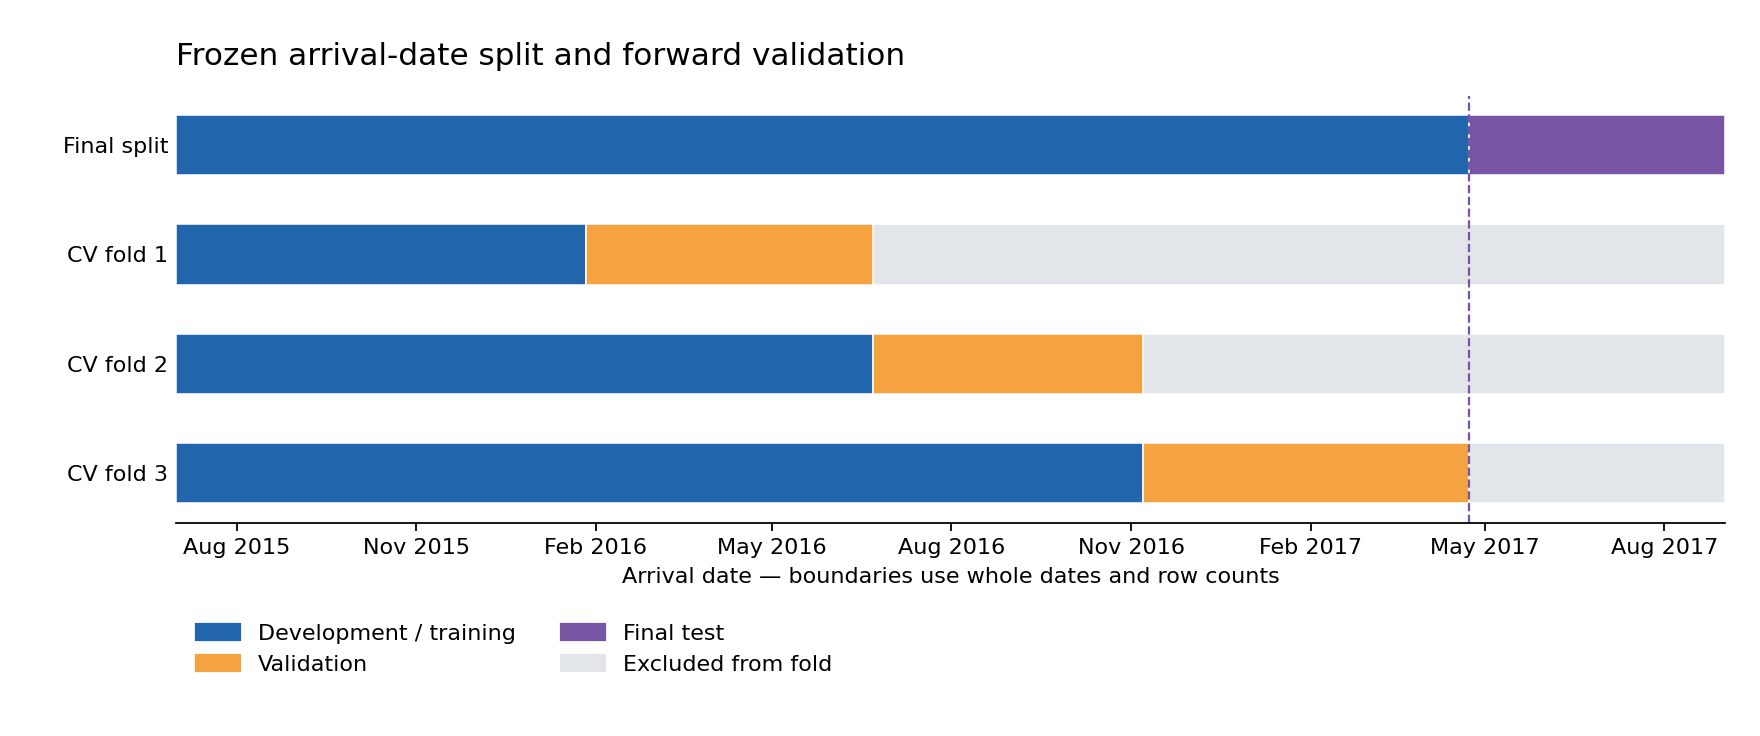

In [8]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from IPython.display import Image

start = pd.Timestamp(split_plan['partitions'][0]['start'])
test_start = pd.Timestamp(split_plan['test_start'])
end = pd.Timestamp(split_plan['partitions'][1]['end']) + pd.Timedelta(days=1)
fig, ax = plt.subplots(figsize=(11, 4.6))
colors = {'train': '#2166AC', 'validation': '#F4A340', 'excluded': '#E2E5E9', 'test': '#7755A4'}
def segment(ypos, begin, finish, color):
    ax.barh(ypos, (finish - begin).days, left=mdates.date2num(begin), height=0.55,
            color=color, edgecolor='white', linewidth=0.7)
segment(3, start, test_start, colors['train'])
segment(3, test_start, end, colors['test'])
for fold in split_plan['folds']:
    ypos = 3 - fold['fold']
    val_start = pd.Timestamp(fold['validation']['start'])
    val_end = pd.Timestamp(fold['validation']['end']) + pd.Timedelta(days=1)
    segment(ypos, start, end, colors['excluded'])
    segment(ypos, start, val_start, colors['train'])
    segment(ypos, val_start, val_end, colors['validation'])
ax.axvline(mdates.date2num(test_start), color='#7755A4', linestyle='--', linewidth=1)
ax.set_yticks([3, 2, 1, 0], ['Final split', 'CV fold 1', 'CV fold 2', 'CV fold 3'])
ax.xaxis_date()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.set_xlim(mdates.date2num(start), mdates.date2num(end))
ax.set_title('Frozen arrival-date split and forward validation', loc='left', fontsize=14, pad=14)
ax.set_xlabel('Arrival date — boundaries use whole dates and row counts')
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.tick_params(axis='y', length=0)
ax.legend(handles=[Patch(color=colors['train'], label='Development / training'),
                   Patch(color=colors['validation'], label='Validation'),
                   Patch(color=colors['test'], label='Final test'),
                   Patch(color=colors['excluded'], label='Excluded from fold')],
          loc='upper left', bbox_to_anchor=(0, -0.19), ncol=2, frameon=False)
fig.subplots_adjust(bottom=0.29, left=0.10, right=0.98, top=0.87)
figure_path = ROOT / 'figures/02_evaluation_timeline.png'
fig.savefig(figure_path, dpi=160, facecolor='white')
plt.close(fig)
display(Image(filename=str(figure_path)))


## 10. Frozen metric and model-selection protocol

- **Primary:** cancellation-class F1 (`is_canceled=1`), arithmetic mean across the three forward validation folds. Report each fold and its variability, too. Use `zero_division=0` where needed.
- **Secondary:** accuracy, precision, recall, and ROC-AUC; compute ROC-AUC from probabilities or decision scores, not class predictions.
- **Models planned:** majority-class dummy baseline, logistic regression, and random forest. Use the same folds for every comparison.
- **Default probability threshold:** 0.5. If threshold tuning is used, choose it only with development validation and freeze it before the final test.
- **Seed:** splitting is deterministic with no random seed. Set random state 42 for stochastic models/searches later; document any further randomness.
- **Leakage control:** fit imputation, scaling, encoding, dimensionality reduction, and feature selection inside each training fold. Use `cv=development_cv(assignments)` with development data only.
- **Final evaluation:** after selecting all settings, refit on all 95,415 development rows. Evaluate the reserved test set once in Step 13. Do not choose models or change the split based on the test result.

This is a retrospective check of generalization to later arrival cohorts. No temporal embargo or live label-availability reconstruction is applied. The original source does not provide reliable booking-creation snapshots; fields such as room assignments and booking changes need further availability review. Seasonal changes and unequal calendar durations must be discussed with the results. No model accuracy is claimed at Step 6.


In [9]:
assignment_path = SPLIT_DIR / split_plan['assignment_file']
frozen_before = {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                 for p in [assignment_path, SPLIT_DIR / 'step6_split_plan.json']}
assert hashlib.sha256(assignment_path.read_bytes()).hexdigest() == split_plan['assignment_sha256']
reloaded = pd.read_csv(assignment_path)
pd.testing.assert_frame_equal(reloaded, assignments)
again, again_plan = run_step6(OUTPUT_DIR, SPLIT_DIR)
pd.testing.assert_frame_equal(again, assignments)
assert again_plan == split_plan
assert frozen_before == {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                         for p in [assignment_path, SPLIT_DIR / 'step6_split_plan.json']}
for name, expected_sha in split_plan['upstream_output_sha256'].items():
    assert hashlib.sha256((OUTPUT_DIR / name).read_bytes()).hexdigest() == expected_sha
assert hashlib.sha256(RAW_PATH.read_bytes()).hexdigest() == source_before
print('PASS: split artifacts reload correctly and rerunning preserves their bytes.')
print('PASS: Step 5 data and original CSV are unchanged. No model or test performance evaluated.')


PASS: split artifacts reload correctly and rerunning preserves their bytes.
PASS: Step 5 data and original CSV are unchanged. No model or test performance evaluated.


## 11. Step 7 — Domain rules and preprocessing

| Issue | Applied rule | Learned from |
| --- | --- | --- |
| Company ID | Exclude sparse nominal identifier; possible presence feature deferred to Step 9 | Fixed policy, before model results |
| Assigned room, booking changes, waiting-list days | Exclude three fields potentially updated after booking | Fixed conservative availability policy |
| Negative ADR | Convert the value to missing; retain the row | Fixed nonnegative-price assumption |
| Numeric missing values | Median imputation, with zero fallback only if an entire training field is missing | Training fold only |
| Missing country / other ordinary categories | Explicit `Unknown` category | Fixed semantics |
| Missing agent | Explicit `NoAgent`; present integer codes become strings | Source NULL convention; not generic unknown |
| Existing `Undefined` category | Preserve separately from `Unknown` | Fixed semantics |
| Skewed numeric fields | `log1p` for lead time, prior cancellations, prior noncanceled bookings, and ADR after imputation | Fixed transform; no fitted cutoff |
| Numeric scaling | StandardScaler after imputation/log transform; optional unscaled variant for trees | Training fold only |
| Categorical encoding | Sparse one-hot encoding; unseen categories produce zeros for that field | Training vocabulary only |
| Unknown child count / invalid or missing ADR | Always include two missing indicators | Fixed feature schema |

These rules remove **no additional rows**. Zero ADR and high positive ADR are retained. The source and frozen partitions are unchanged. Target/status fields and split metadata are rejected if accidentally passed to the preprocessor. Undeclared derived fields are also rejected, requiring an explicit schema extension in Step 9 rather than silently losing them.

The four policy exclusions do not replace the statistical feature-selection and dimensionality-reduction work required in Step 10. The named research factors (lead time, deposit type, prior cancellations) remain present.


In [10]:
from src.preprocessing import make_preprocessor, POLICY_EXCLUSIONS, MODEL_COLUMNS
from src.preprocessing_audit import run_preprocessing_audit

preprocessing_summary, feature_schemas = run_preprocessing_audit(ROOT)
assert preprocessing_summary['development_rows'] == 95415
assert preprocessing_summary['test_rows_fitted_or_transformed'] == 0
assert preprocessing_summary['rows_removed'] == 0
assert preprocessing_summary['retained_source_field_count'] == 25
display(pd.DataFrame([{
    'fold': f['fold'], 'training_rows': f['training']['rows'],
    'validation_rows': f['validation']['rows'], 'encoded_features': f['training']['columns'],
    'training_nonfinite': f['training']['nonfinite_values'],
    'validation_nonfinite': f['validation']['nonfinite_values'],
    'validation_changed_fitted_state': not f['validation_did_not_change_fitted_state']
} for f in preprocessing_summary['folds']]))
display(pd.Series(POLICY_EXCLUSIONS, name='Reason excluded from initial input schema').to_frame())


,fold,training_rows,validation_rows,encoded_features,training_nonfinite,validation_nonfinite,validation_changed_fitted_state
0,1,23797,23893,328,0,0,False
1,2,47690,23776,422,0,0,False
2,3,71466,23949,491,0,0,False


,Reason excluded from initial input schema
company,Sparse company identifier; possible presence f...
assigned_room_type,Assignment can change after reservation; exclu...
booking_changes,Accumulated post-reservation changes; timing i...
days_in_waiting_list,Accumulated waiting time; timing is uncertain.


## 12. Before/after missingness and fitted statistics

Training windows overlap by design: do not add counts across folds as if they were distinct records. Missing counts below are measured after negative ADR is marked missing, before median imputation. All resulting numeric and categorical matrices are finite. The four missing child counts are imputed to zero in these actual folds because their training medians are zero; the missing flags distinguish them from observed zeros.


In [11]:
before_after = []
for f in preprocessing_summary['folds']:
    for partition in ['training', 'validation']:
        missing = f[partition + '_missing_numeric_before_imputation']
        before_after.append({
            'fold': f['fold'], 'partition': partition,
            'children_missing_before': missing.get('children', 0),
            'adr_missing_before': missing.get('adr', 0),
            'country_to_Unknown': f[partition + '_country_missing_to_unknown'],
            'agent_to_NoAgent': f[partition + '_agent_missing_to_no_agent'],
            'nonfinite_after': f[partition]['nonfinite_values']
        })
display(pd.DataFrame(before_after))
display(pd.DataFrame([{
    'fold': f['fold'], 'scaler_rows_seen': f['numeric_scaler_rows_seen'],
    'children_training_median': f['training_medians']['children'],
    'ADR_training_median': f['training_medians']['adr'],
    'validation_negative_ADR_imputed': f['validation_negative_adr_to_missing']
} for f in preprocessing_summary['folds']]))


,fold,partition,children_missing_before,adr_missing_before,country_to_Unknown,agent_to_NoAgent,nonfinite_after
0,1,training,4,0,158,3471,0
1,1,validation,0,0,123,3359,0
2,2,training,4,0,281,6830,0
3,2,validation,0,0,72,2434,0
4,3,training,4,0,353,9264,0
5,3,validation,0,1,120,4481,0


,fold,scaler_rows_seen,children_training_median,ADR_training_median,validation_negative_ADR_imputed
0,1,23797,0.0,76.50,0
1,2,47690,0.0,80.75,0
2,3,71466,0.0,90.00,1


## 13. Category changes and high-price handling

Encoded feature counts differ across folds because vocabularies are fitted only on their training rows. Train and validation widths must match **within** a fold; columns must not be pooled by position across folds. The first training period contains only part of a calendar year, so most of its validation months are unseen. Their month block becomes zeros, as documented. Other date fields remain, but seasonal coverage is a limitation; consider cyclic calendar features in Step 9 without changing the frozen split.

The sole ADR above 1,000 lies in fold 1 validation and later enters training. It is preserved and transformed with log1p, without learning a cap from validation. The negative ADR lies in fold 3 validation and is imputed using the training median of 90. No row is removed in either case.


In [12]:
display(pd.DataFrame([{
    'fold': f['fold'],
    **{col: f['validation_unseen_category_rows_by_field'][col]
       for col in ['arrival_date_month', 'country', 'market_segment', 'agent']}
} for f in preprocessing_summary['folds']]))
display(pd.DataFrame([{
    'fold': f['fold'], 'train_zero_ADR_retained': f['training_zero_adr_retained'],
    'validation_zero_ADR_retained': f['validation_zero_adr_retained'],
    'train_ADR_above_1000_retained': f['training_adr_above_1000_retained'],
    'validation_ADR_above_1000_retained': f['validation_adr_above_1000_retained']
} for f in preprocessing_summary['folds']]))
assert np.isfinite(np.log1p(5400))
print('Fixed transform example: log1p(5400) =', round(float(np.log1p(5400)), 6))
print('No predictive model has been trained or evaluated in Step 7.')


Fixed transform example: log1p(5400) = 8.594339
No predictive model has been trained or evaluated in Step 7.


,fold,arrival_date_month,country,market_segment,agent
0,1,23475,114,62,1531
1,2,0,31,0,349
2,3,0,15,0,613


,fold,train_zero_ADR_retained,validation_zero_ADR_retained,train_ADR_above_1000_retained,validation_ADR_above_1000_retained
0,1,607,402,0,1
1,2,1009,261,1,0
2,3,1270,352,1,0


## 14. Reuse safely in later modeling

Use the factory inside a model pipeline. This example is a future modeling pattern; it is **not executed here**:

```python
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from src.preprocessing import make_preprocessor
from src.splitting import development_cv

pipeline = Pipeline([
    ('preprocess', make_preprocessor()),
    ('model', LogisticRegression(max_iter=2000, random_state=42)),
])
search = GridSearchCV(pipeline, {'model__C': [0.1, 1.0, 10.0]},
                      scoring='f1', cv=development_cv(assignments))
# Step 11/12, after adding the required Step 9/10 components:
# search.fit(X_dev, y_dev)
```

For a tree model, use `make_preprocessor(scale_numeric=False)`. Both factory variants were verified on all three folds. Do not fit one preprocessor on all development data and then run CV on that transformed matrix. Do not fit or transform the final test set until the final pipeline is selected. Stored schemas and audit summaries are diagnostic evidence, not a globally fitted preprocessing artifact.

In [13]:
step7_dir = OUTPUT_DIR / 'step7'
assert json.loads((step7_dir / 'preprocessing_summary.json').read_text()) == preprocessing_summary
assert json.loads((step7_dir / 'feature_schemas.json').read_text()) == feature_schemas
for f in preprocessing_summary['folds']:
    assert f['training']['columns'] == f['validation']['columns'] == len(feature_schemas[f"fold_{f['fold']}"])
    assert f['numeric_scaler_rows_seen'] == f['training']['rows']
    assert f['validation_did_not_change_fitted_state']
for filename, expected_sha in split_plan['upstream_output_sha256'].items():
    assert hashlib.sha256((OUTPUT_DIR / filename).read_bytes()).hexdigest() == expected_sha
assert frozen_before == {p.name: hashlib.sha256(p.read_bytes()).hexdigest()
                         for p in [assignment_path, SPLIT_DIR / 'step6_split_plan.json']}
assert hashlib.sha256(RAW_PATH.read_bytes()).hexdigest() == source_before
print('PASS: Step 7 summaries/schemas saved; training-only medians, scaling, and vocabularies verified.')
print('PASS: Step 5 data, Step 6 partitions, and original CSV unchanged.')


PASS: Step 7 summaries/schemas saved; training-only medians, scaling, and vocabularies verified.
PASS: Step 5 data, Step 6 partitions, and original CSV unchanged.
